In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib_venn import venn2, venn3
from upsetplot import UpSet, from_indicators
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

purple_muted = '#8E8AB8'   # parental / wild-type
green_muted  = '#7FA77F'   # variant family
blue_pair    = '#5A8DC8'   # single / category A
gold_pair    = '#E8B85F'   # combination / category B
red_ctrl     = '#C86A6A'   # negative controls
gray_bg      = '#C8C8C8'   # background scatter

# sequential blues (panel i)
blues_5 = sns.color_palette('Blues', 6)[1:]   # skip lightest
# sequential greens (panel j)
greens_5 = sns.color_palette('Greens', 6)[1:]

# diverging (panel e)
diverging = sns.diverging_palette(230, 20, s=60, l=70, as_cmap=True)

## 3a

Composition of the focused ABE library.


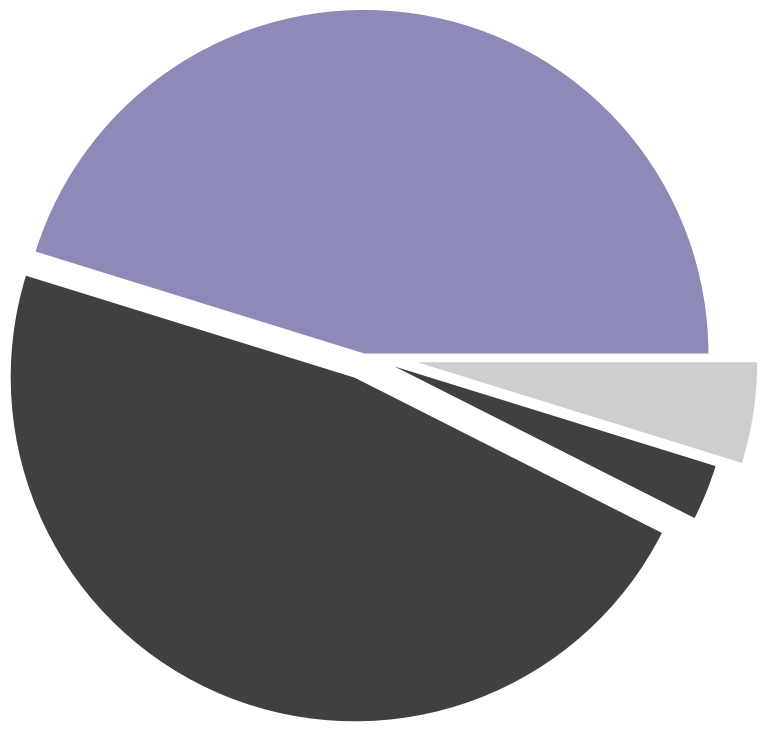

In [5]:
# a pie ploy showing the composition of the focused CBE library
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
mypie, _ = ax.pie([170, 178, 10, 18], radius = 1.4, colors = [purple_muted, plt.cm.Greys(.8), plt.cm.Greys(.8), plt.cm.Greys(.3)],
                  explode = (0,.1,.1, .2))
plt.savefig('figures/3/3a.pdf', bbox_inches = 'tight', dpi=300)
plt.setp(mypie, edgecolor='white')
plt.show()

In [ ]:
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

dfs = {
    'ABE_OG':         pd.read_csv(BASE + 'LFC-FDR/ABE_OG_LFC_FDR.csv', low_memory=False),
    'CBE_OG':         pd.read_csv(BASE + 'LFC-FDR/CBE_OG_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0':     pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_T0':     pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_BC':     pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_BC':     pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'ABE_BC_T0':      pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'CBE_BC_T0':      pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0_FSR': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_EPO_T0_FSR': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR_FSR.csv', low_memory=False),
    'ABE_EPO_BC_FSR': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_EPO_BC_FSR': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR_FSR.csv', low_memory=False),
    'ABE_BC_T0_FSR':  pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_BC_T0_FSR':  pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR_FSR.csv', low_memory=False),
}

# Conditions with FDR calculated
conds_og      = ['d15', 'bm', 'spleen', 'men']
conds_focused = ['d15', 'bm', 'spleen']

# Per-replicate raw count columns per condition per screen
rep_cols = {
    'ABE_OG':         {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4'],
                       'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_OG':         {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4'],
                       'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_T0':     {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_T0':     {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                       'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_BC':     {'bm':    ['bm1','bm3','bm5'],
                       'spleen':['spleen1','spleen3'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_BC':     {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                       'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_BC_T0':      {'bm':    ['bm1','bm3','bm5'],
                       'spleen':['spleen1','spleen3'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_BC_T0':      {'bm':    ['bm1','bm3','bm4','bm5','bm7','bm8','bm9'],
                       'spleen':['spleen1','spleen3','spleen4','spleen5','spleen7','spleen8','spleen9'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    # FSR screens — d15 cols are 'd15-1','d15-2','d15-3'
    'ABE_EPO_T0_FSR': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_EPO_T0_FSR': {'bm':    ['bm1','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'ABE_EPO_BC_FSR': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_EPO_BC_FSR': {'bm':    ['bm1','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'ABE_BC_T0_FSR':  {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_BC_T0_FSR':  {'bm':    ['bm2','bm3','bm4','bm5'],
                       'spleen':['spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
}

# COSMIC cancer gene census
cosmic = pd.read_csv(BASE + 'source-data/Census_allSun Nov 17 02_26_47 2024.csv').fillna('Undefined')
t_dict = {
    'TSG': 'TSG', 'TSG, fusion': 'TSG',
    'Undefined': 'Undefined', 'fusion': 'Undefined',
    'oncogene': 'Oncogene',
    'oncogene, TSG': 'Oncogene/TSG', 'oncogene, TSG, fusion': 'Oncogene/TSG',
    'oncogene, fusion': 'Oncogene',
}
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple',
              'TSG':'tab:blue', 'Undefined':'tab:grey'}

def add_cosmic(df):
    gene_col = 'gene_name_h' if 'gene_name_h' in df.columns else 'Gene'
    roles = []
    for v in df[gene_col]:
        sub = cosmic[cosmic['Gene Symbol'] == v]
        roles.append('Undefined' if len(sub)==0 else t_dict.get(sub['Role in Cancer'].values[0], 'Undefined'))
    df = df.copy()
    df['Role in Cancer'] = roles
    df['color'] = [color_dict[r] for r in roles]
    return df

for key in dfs:
    dfs[key] = add_cosmic(dfs[key])

print('Loaded:')
for k, v in dfs.items():
    print(f'  {k}: {len(v)} guides')


Loaded:
  ABE_OG: 1070 guides
  CBE_OG: 13242 guides
  ABE_EPO_T0: 376 guides
  CBE_EPO_T0: 1257 guides
  ABE_EPO_BC: 376 guides
  CBE_EPO_BC: 1257 guides
  ABE_BC_T0: 376 guides
  CBE_BC_T0: 1257 guides
  ABE_EPO_T0_FSR: 376 guides
  CBE_EPO_T0_FSR: 1257 guides
  ABE_EPO_BC_FSR: 376 guides
  CBE_EPO_BC_FSR: 1257 guides
  ABE_BC_T0_FSR: 376 guides
  CBE_BC_T0_FSR: 1257 guides


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


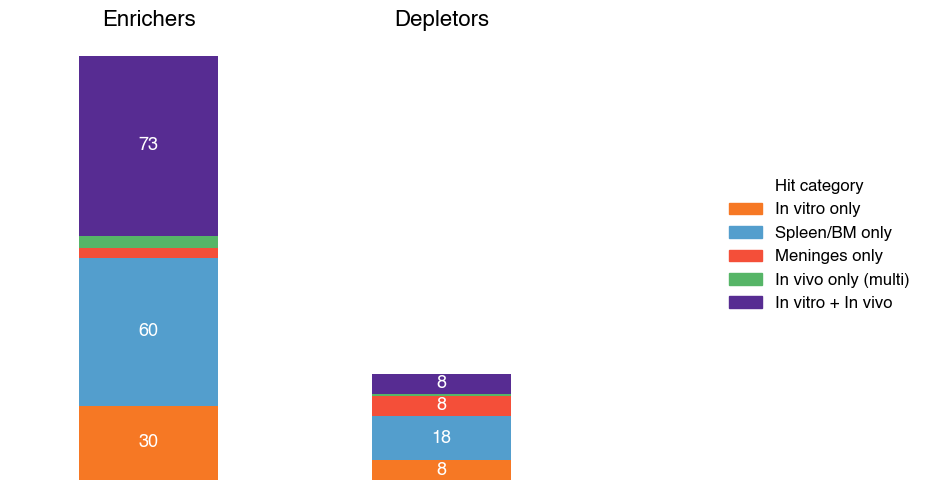

In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────────
min_edit   = 10
FDR_cutoff = 0.1
LFC_cutoff = 1.0
min_sensors = 10
names_og   = ['d15', 'spleen', 'bm', 'men']

# ── Load & filter targeting guides ────────────────────────────────────────────
ABE_OG = dfs['ABE_OG']
edit_cols = [f'target_base_edit_perc_{t}' for t in names_og]
targ = ABE_OG[
    (ABE_OG['classification'] == 'targeting guide') &
    (ABE_OG[edit_cols].max(axis=1) >= min_edit)
].copy()

# ── Assign tissue category per guide ─────────────────────────────────────────
def assign_category(row, direction):
    lfc_sign = -1 if direction == 'dep' else 1
    hit_tissues = []
    for t in names_og:
        lfc = row.get(f'LFC_median_{t}', np.nan)
        fdr = row.get(f'FDR_{t}_fishers', 1.0)
        if pd.notna(lfc) and fdr <= FDR_cutoff and lfc * lfc_sign >= LFC_cutoff:
            hit_tissues.append(t)
    if not hit_tissues:
        return None
    s = set(hit_tissues)
    if s <= {'d15'}:
        return 'In vitro only'
    if s <= {'spleen', 'bm'}:
        return 'Spleen/BM only'
    if s <= {'men'}:
        return 'Meninges only'
    if s <= {'spleen', 'bm', 'men'}:
        return 'In vivo only (multi)'
    return 'In vitro + In vivo'

targ['cat_dep'] = targ.apply(lambda r: assign_category(r, 'dep'), axis=1)
targ['cat_enr'] = targ.apply(lambda r: assign_category(r, 'enr'), axis=1)

dep_counts = targ[targ['cat_dep'].notna()]['cat_dep'].value_counts()
enr_counts = targ[targ['cat_enr'].notna()]['cat_enr'].value_counts()

# ── Plot ──────────────────────────────────────────────────────────────────────
cat_order = ['In vitro only', 'Spleen/BM only', 'Meninges only',
             'In vivo only (multi)', 'In vitro + In vivo']

palette_cat = {
    'In vitro only':        yellows[3],
    'Spleen/BM only':       blues[3],
    'Meninges only':        reds[3],
    'In vivo only (multi)': greens[3],
    'In vitro + In vivo':   purples[5],
}

fig, axes = plt.subplots(1, 2, figsize=(6, 5), sharey=True)

for ax, counts, title in zip(axes,
                              [enr_counts, dep_counts],
                              ['Enrichers', 'Depletors']):
    bottom = 0
    for cat in cat_order:
        val = counts.get(cat, 0)
        if val == 0:
            continue
        ax.bar(0, val, bottom=bottom,
               color=palette_cat[cat], edgecolor='none',
               label=cat, width=0.5)
        if val > 5:
            ax.text(0, bottom + val/2, str(val),
                    ha='center', va='center', fontsize=13, color='white', fontweight='bold')
        bottom += val
    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([])
    ax.set_title(title, fontsize=16)
    ax.set_ylabel('')
    ax.set_yticks([])
    ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

handles = [mpl.patches.Patch(color=palette_cat[c], label=c) for c in cat_order]
fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.55, 0.5),
           fontsize=12, frameon=False, title='Hit category', title_fontsize=12)
fig.tight_layout()
plt.savefig(BASE + 'figures/3/3a-2.pdf', bbox_inches='tight', dpi=300)
plt.show()


## 3b

Venn plot showing the overlap between enrichers and depleters in the OG and focused ABE screens.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


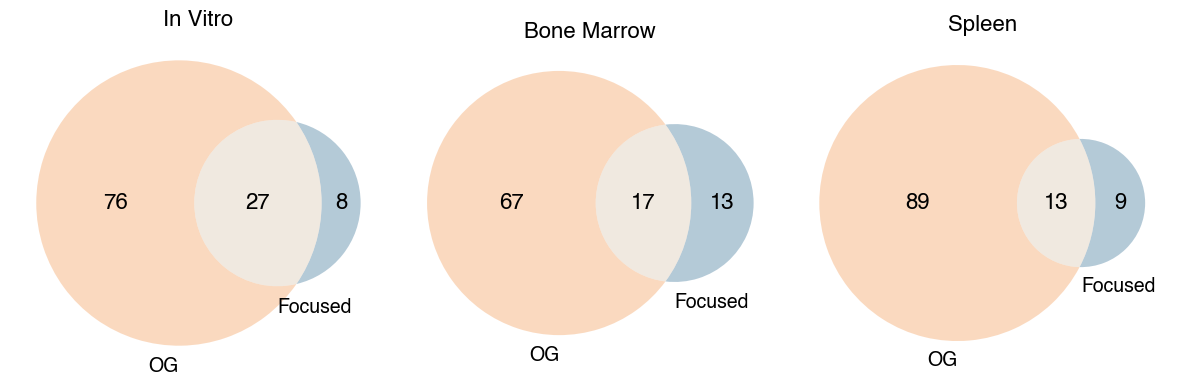

In [44]:
from matplotlib_venn import venn2

min_edit           = 10
FDR_cutoff         = 0.1
LFC_cutoff         = 1.0
min_sensor_og      = 10
min_sensor_focused = 100

ABE_OG  = dfs['ABE_OG']
ABE_EPO = dfs['ABE_EPO_T0']

cond_list   = ['d15', 'bm', 'spleen']
cond_labels = {'d15': 'In Vitro', 'bm': 'Bone Marrow', 'spleen': 'Spleen'}

# guides present in focused library
focused_guides = set(ABE_EPO['gRNA_id'])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, cond in zip(axes, cond_list):
    fdr_col    = f'FDR_{cond}_fishers'
    lfc_col    = f'LFC_median_{cond}'
    edit_col   = f'target_base_edit_perc_{cond}'
    sensor_col = f'sensor_reads_{cond}'

    og_targ = ABE_OG[
        (ABE_OG['classification'] == 'targeting guide') &
        (ABE_OG['gRNA_id'].isin(focused_guides))   # only guides in focused library
    ].copy()
    if sensor_col in og_targ.columns:
        og_targ = og_targ[og_targ[sensor_col] >= min_sensor_og]
    og_targ = og_targ[og_targ[edit_col] >= min_edit][['gRNA_id', fdr_col, lfc_col]]

    epo_targ = ABE_EPO[ABE_EPO['classification'] == 'targeting guide'].copy()
    if sensor_col in epo_targ.columns:
        epo_targ = epo_targ[epo_targ[sensor_col] >= min_sensor_focused]
    epo_targ = epo_targ[epo_targ[edit_col] >= min_edit][['gRNA_id', fdr_col, lfc_col]]

    og_hits  = set(og_targ.loc[ (og_targ[fdr_col]  <= FDR_cutoff) & (og_targ[lfc_col].abs()  >= LFC_cutoff), 'gRNA_id'])
    epo_hits = set(epo_targ.loc[(epo_targ[fdr_col] <= FDR_cutoff) & (epo_targ[lfc_col].abs() >= LFC_cutoff), 'gRNA_id'])

    v = venn2([og_hits, epo_hits],
              set_labels=('OG', 'Focused'),
              set_colors=('#f4a26188', '#457b9d88'),
              ax=ax)
    for text in v.set_labels:
        if text: text.set_fontsize(14)
    for text in v.subset_labels:
        if text: text.set_fontsize(16)

    ax.set_title(cond_labels[cond], fontsize=16)

fig.tight_layout()
plt.savefig(BASE + 'figures/3/3b.pdf', bbox_inches='tight', dpi=300)
plt.show()


## 3c

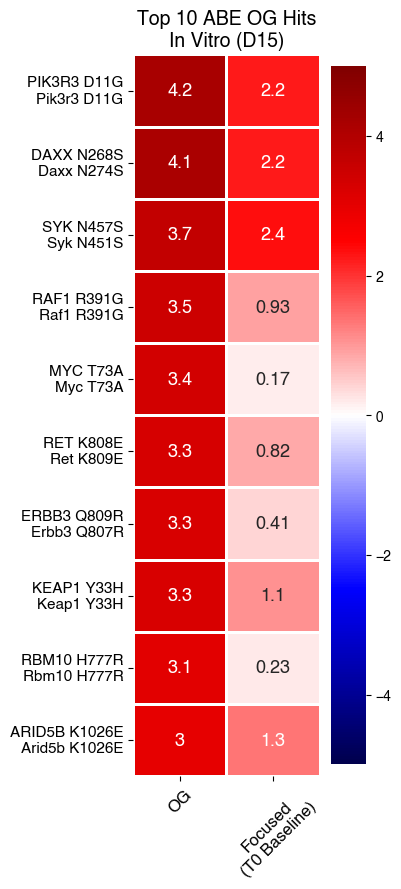

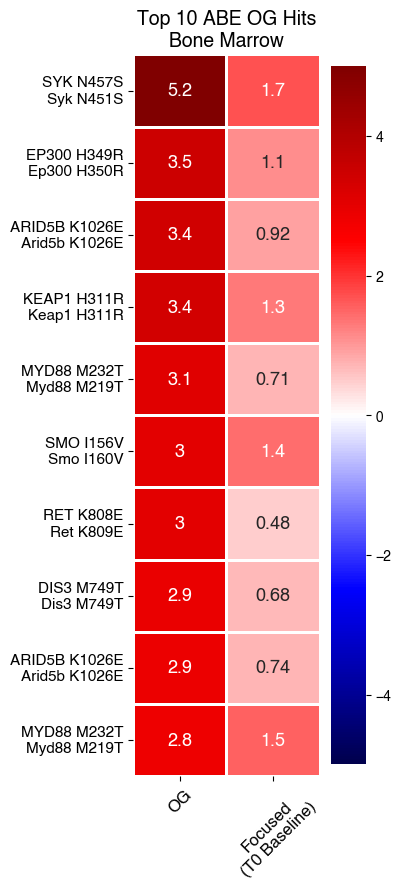

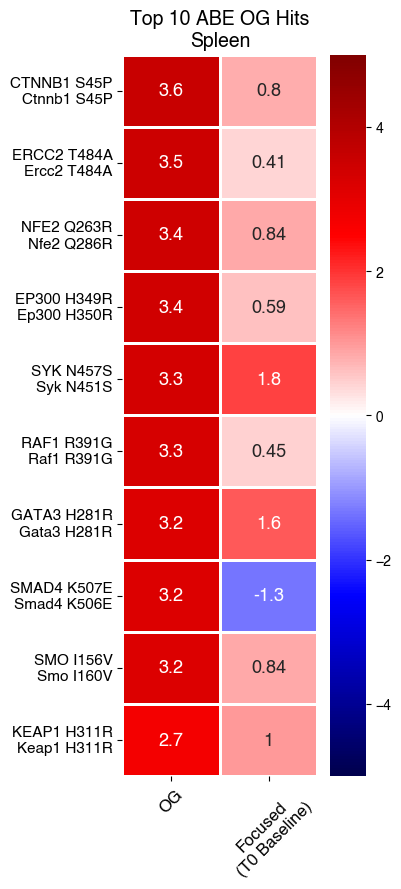

In [47]:
min_edit           = 10
FDR_cutoff         = 0.1
LFC_cutoff         = 1.0
min_sensor_og      = 10
min_sensor_focused = 100

ABE_OG  = dfs['ABE_OG']
ABE_EPO = dfs['ABE_EPO_T0']

cond_list   = ['d15', 'bm', 'spleen']
cond_labels = {'d15': 'In Vitro (D15)', 'bm': 'Bone Marrow', 'spleen': 'Spleen'}

for cond in cond_list:
    fdr_col    = f'FDR_{cond}_fishers'
    lfc_col    = f'LFC_median_{cond}'
    z_col      = f'z_score_median_{cond}'
    edit_col   = f'target_base_edit_perc_{cond}'
    sensor_col = f'sensor_reads_{cond}'

    # filter OG hits
    og = ABE_OG[ABE_OG['classification'] == 'targeting guide'].copy()
    if sensor_col in og.columns:
        og = og[og[sensor_col] >= min_sensor_og]
    og = og[og['Input_median'] >= 2]
    og = og[
        (og[edit_col]  >= min_edit) &
        (og[fdr_col]   <= FDR_cutoff) &
        (og[lfc_col].abs() >= LFC_cutoff)
    ].copy()

    og = og.sort_values(by=z_col, ascending=False).reset_index(drop=True)
    top = og.iloc[:10].copy()

    # get focused z-score for same guides
    epo = ABE_EPO[['gRNA_id', z_col]].rename(columns={z_col: 'z_focused'})
    top = pd.merge(top[['gRNA_id', z_col, 'gene_name_h', 'HGVSp_h', 'Gene', 'HGVSp_m']], epo, on='gRNA_id', how='left')
    top = top.rename(columns={z_col: 'z_og'})

    # y-axis labels
    labels = []
    for _, row in top.iterrows():
        hgvs_h = row['HGVSp_h'] if isinstance(row['HGVSp_h'], str) else 'Non-coding'
        labels.append(f"{row['gene_name_h']} {hgvs_h}\n{row['Gene']} {row['HGVSp_m']}")

    fig, ax = plt.subplots(figsize=(4, 9))
    g = sns.heatmap(
        top[['z_og', 'z_focused']],
        cmap='seismic', annot=True, annot_kws={'size': 13},
        linewidth=1, edgecolor='white',
        vmin=-5, vmax=5, ax=ax
    )
    g.set_yticklabels(labels, rotation=0, fontsize=11)
    g.set_xticklabels(['OG', 'Focused\n(T0 Baseline)'], rotation=45, fontsize=12)
    ax.set_title(f'Top 10 ABE OG Hits\n{cond_labels[cond]}', fontsize=14)
    fig.tight_layout()
    plt.savefig(f'figure3c_top10_OG_{cond}.pdf', bbox_inches='tight')
    plt.show()


## 3d

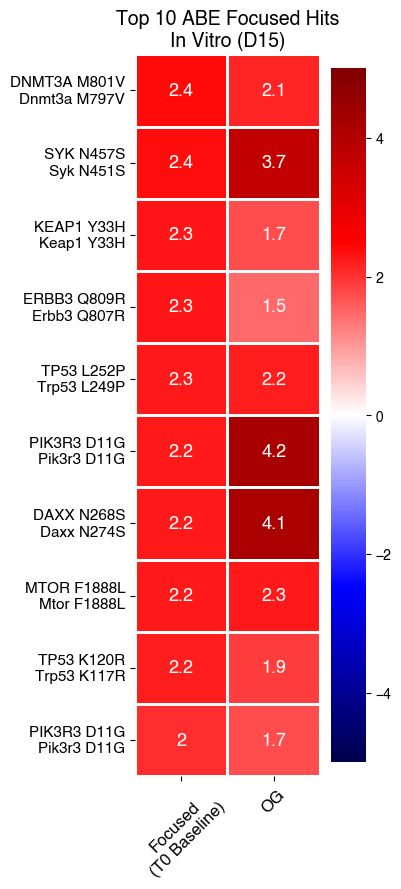

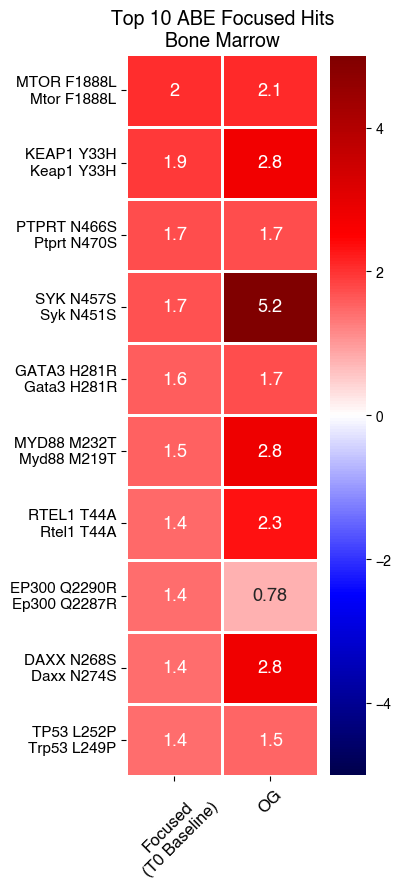

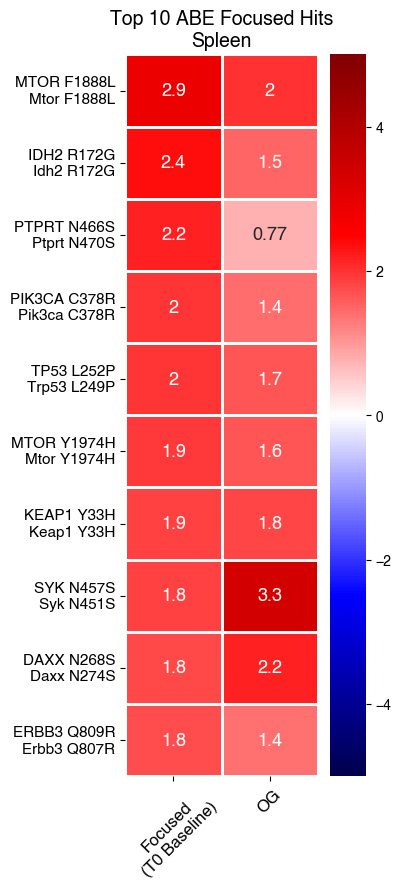

In [48]:
for cond in cond_list:
    fdr_col    = f'FDR_{cond}_fishers'
    lfc_col    = f'LFC_median_{cond}'
    z_col      = f'z_score_median_{cond}'
    edit_col   = f'target_base_edit_perc_{cond}'
    sensor_col = f'sensor_reads_{cond}'

    # filter Focused hits
    epo = ABE_EPO[ABE_EPO['classification'] == 'targeting guide'].copy()
    if sensor_col in epo.columns:
        epo = epo[epo[sensor_col] >= min_sensor_focused]
    epo = epo[epo['Input_median'] >= 2]
    epo = epo[
        (epo[edit_col]  >= min_edit) &
        (epo[fdr_col]   <= FDR_cutoff) &
        (epo[lfc_col].abs() >= LFC_cutoff)
    ].copy()
    epo = epo.sort_values(by=z_col, ascending=False).reset_index(drop=True)
    top = epo.iloc[:10].copy()

    # get OG z-score for same guides
    og = ABE_OG[['gRNA_id', z_col]].rename(columns={z_col: 'z_og'})
    top = pd.merge(top[['gRNA_id', z_col, 'gene_name_h', 'HGVSp_h', 'Gene', 'HGVSp_m']], og, on='gRNA_id', how='left')
    top = top.rename(columns={z_col: 'z_focused'})

    # y-axis labels
    labels = []
    for _, row in top.iterrows():
        hgvs_h = row['HGVSp_h'] if isinstance(row['HGVSp_h'], str) else 'Non-coding'
        labels.append(f"{row['gene_name_h']} {hgvs_h}\n{row['Gene']} {row['HGVSp_m']}")

    fig, ax = plt.subplots(figsize=(4, 9))
    g = sns.heatmap(
        top[['z_focused', 'z_og']],
        cmap='seismic', annot=True, annot_kws={'size': 13},
        linewidth=1, edgecolor='white',
        vmin=-5, vmax=5, ax=ax
    )
    g.set_yticklabels(labels, rotation=0, fontsize=11)
    g.set_xticklabels(['Focused\n(T0 Baseline)', 'OG'], rotation=45, fontsize=12)
    ax.set_title(f'Top 10 ABE Focused Hits\n{cond_labels[cond]}', fontsize=14)
    fig.tight_layout()
    plt.savefig(f'figure3d_top10_Focused_{cond}.pdf', bbox_inches='tight')
    plt.show()
